> **Notebook 3 of 4 - Customer Features & RFM**  
> Input: `data/sales_clean.csv` · Output: `data/rfm.csv`  
> Next: `04_clustering.ipynb`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [2]:
sales_df = pd.read_csv('../data/sales_clean.csv', parse_dates=['InvoiceDate'],
                       dtype={'InvoiceNo': str, 'StockCode': str})
sales_df.shape

(534129, 14)

# 8. Customer-Level Feature Engineering

Transactions are aggregated to one row per customer (guest invoices excluded). `CustomerID` is converted to an integer and used only as the row index, never as a feature.

In [3]:
customer_data = sales_df[sales_df['CustomerID'].notna()].copy()
customer_data['CustomerID'] = customer_data['CustomerID'].astype(int)   # identifier, never a model feature

customer_features = (
    customer_data.groupby('CustomerID')
    .agg(TotalQuantity=('Quantity', 'sum'),
         Orders=('InvoiceNo', 'nunique'),
         Revenue=('TotalLineRevenue', 'sum'),
         UniqueProducts=('StockCode', 'nunique'),
         ActiveDays=('InvoiceDate', lambda x: x.dt.date.nunique()))
)
customer_features['AverageOrderValue'] = customer_features['Revenue'] / customer_features['Orders']

customer_returns = (
    customer_data[customer_data['Quantity'] < 0]
    .groupby('CustomerID')
    .agg(ReturnInvoices=('InvoiceNo', 'nunique'),
         ReturnedQuantity=('Quantity', lambda x: -x.sum()))
)
customer_features = customer_features.join(customer_returns).fillna(0)

customer_features.describe().round(1)

,TotalQuantity,Orders,Revenue,UniqueProducts,ActiveDays,AverageOrderValue,ReturnInvoices,ReturnedQuantity
count,4371.0,4371.0,4371.0,4371.0,4371.0,4371.0,4371.0,4371.0
mean,1116.2,5.1,1894.0,61.2,4.4,314.6,0.8,62.5
std,4662.7,9.3,8219.6,85.4,6.7,361.0,2.1,1682.2
min,-303.0,1.0,-4287.6,1.0,1.0,-4287.6,0.0,0.0
25%,151.5,1.0,291.9,15.0,1.0,151.5,0.0,0.0
50%,364.0,3.0,644.2,35.0,2.0,235.2,0.0,0.0
75%,956.0,5.0,1608.9,77.0,5.0,366.6,1.0,4.0
max,196143.0,248.0,279489.0,1794.0,146.0,6207.7,47.0,80995.0


Features: total quantity, orders, net revenue, unique products, active days, average order value, and return invoices/quantity. The distribution is right-skewed (median revenue £644 vs mean £1,894), and a few customers have negative net revenue because their returns exceed their purchases. These customers are handled in the RFM step.

# 9. RFM Analysis

- **Recency (R):** days since the customer's last purchase (reference date = last invoice date + 1 day).
- **Frequency (F):** number of unique purchase invoices.
- **Monetary (M):** net revenue (purchases minus returns).

Customers whose net revenue is zero or negative (for example, customers who cancelled everything they bought) are excluded from RFM: 21 customers. 33 more customers have only return lines and no purchase. In total **4,317 customers** are analyzed.

In [4]:
reference_date = sales_df['InvoiceDate'].max() + pd.Timedelta(days=1)

purchases = customer_data[customer_data['Quantity'] > 0]

rfm = purchases.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique')
)
# Monetary = net revenue (purchases minus returns)
rfm['Monetary'] = customer_data.groupby('CustomerID')['TotalLineRevenue'].sum().round(2)

# Days since first purchase (used later to profile segments, not for clustering)
first_purchase = purchases.groupby('CustomerID')['InvoiceDate'].min()
rfm['CustomerAge'] = (reference_date - first_purchase).dt.days

print("Customers before filtering:", len(rfm))
print("Customers with Monetary <= 0:", (rfm['Monetary'] <= 0).sum())

rfm = rfm[rfm['Monetary'] > 0].copy()
print("Customers used for RFM:", len(rfm))
rfm.describe().round(1)

Customers before filtering: 4338
Customers with Monetary <= 0: 21
Customers used for RFM: 4317


,Recency,Frequency,Monetary,CustomerAge
count,4317.0,4317.0,4317.0,4317.0
mean,92.2,4.3,1920.7,223.6
std,99.8,7.7,8267.0,117.8
min,1.0,1.0,2.9,1.0
25%,18.0,1.0,301.0,113.0
50%,51.0,2.0,653.8,249.0
75%,141.0,5.0,1624.2,327.0
max,374.0,209.0,279489.0,374.0


### RFM scoring

Each metric is split into 5 equal groups with `pd.qcut`. **Direction:** for Recency a lower number of days gets a *higher* score (5 = most recent, 1–13 days; 1 = 179+ days). For Frequency and Monetary a higher value gets a higher score. Frequency and Monetary are ranked first because many customers share the same value. `555` is the best customer and `111` the weakest.

In [5]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)                       # recent = 5
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,CustomerAge,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,,
12347,2,7,4310.00,367,5,5,5,555
12348,75,4,1797.24,358,2,4,4,244
12349,19,1,1757.55,19,4,1,4,414
12350,310,1,334.40,310,1,1,2,112
12352,36,8,1545.41,297,3,5,4,354


In [6]:
rfm['RFM_Score'].value_counts().head(8)

RFM_Score
555    346
111    191
455    171
121    148
112    120
444    112
122     91
233     90
Name: count, dtype: int64

# 10. RFM Visualization & Interpretation

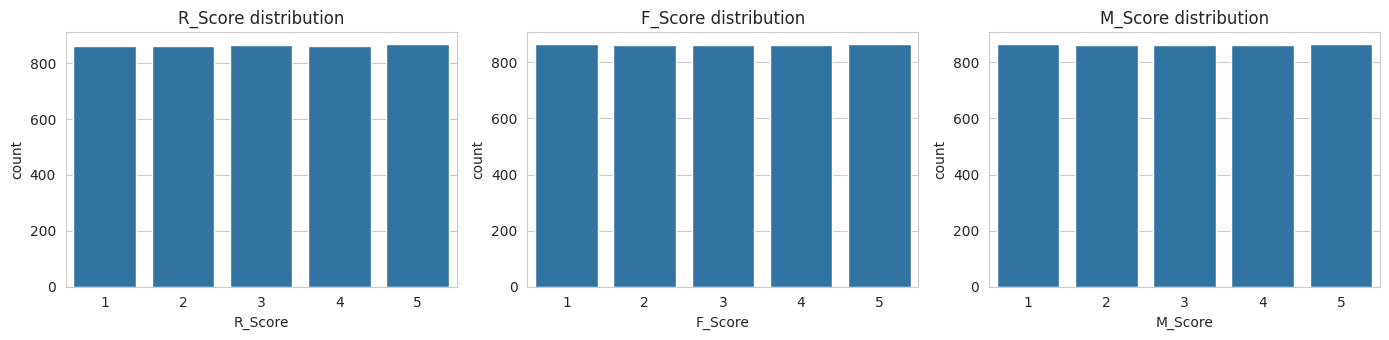

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ['R_Score', 'F_Score', 'M_Score']):
    sns.countplot(data=rfm, x=col, ax=ax)
    ax.set_title(col + ' distribution')
plt.tight_layout()
plt.show()

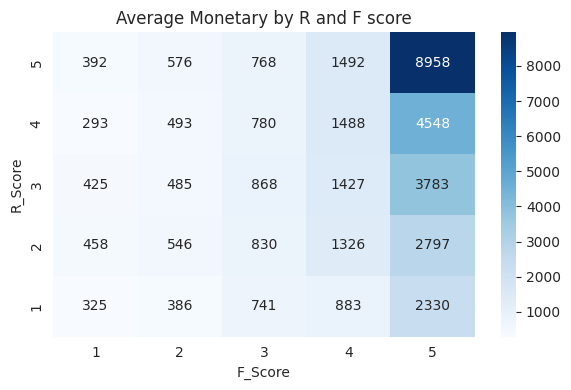

Recency     
            min  max
R_Score             
1           179  374
2            72  178
3            33   71
4            14   32
5             1   13

In [8]:
# Average net spend for every Recency x Frequency score combination
heat = rfm.pivot_table(index='R_Score', columns='F_Score', values='Monetary', aggfunc='mean')

plt.figure(figsize=(6, 4))
sns.heatmap(heat.sort_index(ascending=False), annot=True, fmt='.0f', cmap='Blues')
plt.title('Average Monetary by R and F score')
plt.tight_layout()
plt.show()

rfm.groupby('R_Score')[['Recency']].agg(['min', 'max'])

The score groups are balanced by construction. The most common score is **`555`** (346 customers, 8.0%), followed by `111` (191) and `455` (171), so the base contains many top customers and many lapsed one-time buyers.

The heatmap shows that average spend rises mainly with **Frequency**. Recency matters most among frequent buyers: customers with F = 5 spend about £8,958 on average when R = 5, but £2,330 when R = 1. Frequent buyers who stopped buying have therefore lost most of their value.

In [9]:
# Save the RFM table for the clustering notebook
rfm.to_csv('../data/rfm.csv')
print("Saved:", rfm.shape)

Saved: (4317, 8)
